In [ ]:
# Install libraries
!pip install -q transformers torch pillow matplotlib

# Imports (ONLY ONCE)
from transformers import BlipProcessor, BlipForConditionalGeneration
from PIL import Image
import torch
import matplotlib.pyplot as plt
from google.colab import files

# Load model (ONLY ONCE)
processor = BlipProcessor.from_pretrained("Salesforce/blip-image-captioning-base")
model = BlipForConditionalGeneration.from_pretrained("Salesforce/blip-image-captioning-base")



Loading weights:   0%|          | 0/473 [00:00<?, ?it/s]

The tied weights mapping and config for this model specifies to tie text_decoder.cls.predictions.bias to text_decoder.cls.predictions.decoder.bias, but both are present in the checkpoints, so we will NOT tie them. You should update the config with `tie_word_embeddings=False` to silence this warning
The tied weights mapping and config for this model specifies to tie text_decoder.bert.embeddings.word_embeddings.weight to text_decoder.cls.predictions.decoder.weight, but both are present in the checkpoints, so we will NOT tie them. You should update the config with `tie_word_embeddings=False` to silence this warning
BlipForConditionalGeneration LOAD REPORT from: Salesforce/blip-image-captioning-base
Key                                       | Status     |  | 
------------------------------------------+------------+--+-
text_decoder.bert.embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identic

Saving image9.jpg to image9 (2).jpg
Saving images2.jpg to images2 (2).jpg


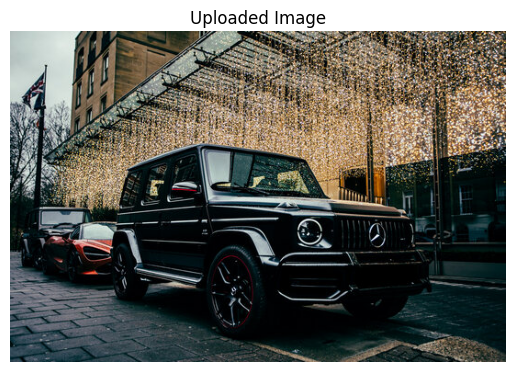


Processing Image: image9 (2).jpg
Generated Captions:
1. mercedes g6 amg with light trail effect package
2. mercedes - g65 luxury - g - line black / black
3. a black mercedes benz parked in the city with trees and lights


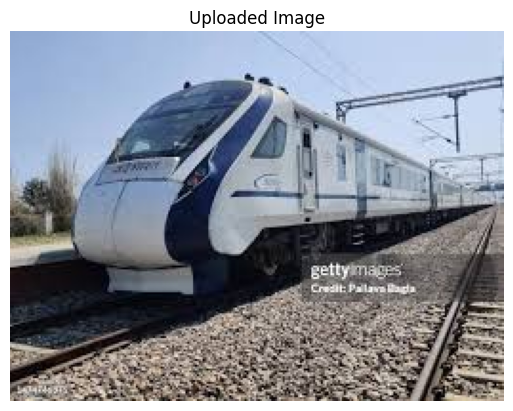


Processing Image: images2 (2).jpg
Generated Captions:
1. a commuter train leaves an area
2. a bullet train arrives at the train station of an israeli national railway station on january 14, 2014 in tel
3. a train passes through the suburbs as it travels along the border


In [ ]:
# Upload image
uploaded = files.upload()

# Loop through uploaded images
for image_name in uploaded.keys():

    # Step 1: Open the image
    image = Image.open(image_name).convert("RGB")

    # Step 2: Display the image
    plt.imshow(image)
    plt.axis("off")
    plt.title("Uploaded Image")
    plt.show()

    # Step 3: Convert image into model input
    inputs = processor(images=image, return_tensors="pt")

    # Step 4: Generate caption
    outputs = model.generate(
        inputs["pixel_values"],
        max_length=30,
        num_return_sequences=3,
        do_sample=True,
        top_k=50,
        top_p=0.95
        )
    print("\nProcessing Image:", image_name)

    print("Generated Captions:")
    for i, out in enumerate(outputs):
      caption = processor.decode(out, skip_special_tokens=True)
      print(f"{i+1}. {caption}")

